<a href="https://colab.research.google.com/github/saraduquej/Analitica-de-negocios/blob/main/Parcial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio:**

Una entidad del sector salud busca implementar un modelo analítico que permita clasificar pacientes con diabetes a partir de sus variables clínicas. Para ello, se utiliza la base de datos Pima Indians Diabetes Database. El propósito es aplicar técnicas de analítica de datos para apoyar la toma de decisiones médicas y mejorar la identificación temprana de pacientes en riesgo.

En este estudio se desarrollan tres modelos: Naive Bayes, Árbol de Decisión (con cuatro niveles) y Clustering K-Means con cinco grupos. Además, se realiza un análisis de correlación para identificar las variables de entrada con mayor relación entre sí y con la variable de salida, permitiendo justificar la relevancia de los predictores utilizados en la clasificación.

De acuerdo con lo anterior, las variables que se analizan son:

- **Pregnancies:** número de veces que la paciente ha estado embarazada.

- **Glucose:** concentración de glucosa en plasma medida dos horas después de realizar una prueba de tolerancia oral a la glucosa.

- **BloodPressure:** presión arterial diastólica medida en milímetros de mercurio (mm Hg).

- **SkinThickness:** espesor del pliegue cutáneo del tríceps medido en milímetros (mm), es un indicador de la cantidad de grasa corporal de una persona.

- **Insulin:** nivel de insulina sérica medido dos horas después de la prueba, expresado en mu U/ml.

- **BMI:** índice de masa corporal, calculado como el peso en kilogramos dividido por la estatura en metros al cuadrado (kg/(m)²).

- **DiabetesPedigreeFunction:** función de historial familiar de diabetes, que resume la información relacionada con antecedentes familiares de la enfermedad.

- **Age:** edad de la paciente expresada en años.

- **Outcome:** variable de salida que indica si la paciente presenta diabetes (1) o no presenta diabetes (0).



##**Modelo Naive Bayes**

**0. Se cargan las librerías de trabajo**

In [ ]:
import numpy as np
import pandas as pd

# Librerias especificas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

#Para eliminar los warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Se carga la base de datos de las pacientes**

In [ ]:
nxl = '/content/drive/MyDrive/Analítica de negocios/diabetes.xlsx'
XDB = pd.read_excel(nxl,sheet_name=0)
XDB.head()

# Seleccionamos las variables de trabajo
XD = XDB [['Pregnancies', 'Glucose','BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
XD.head(10)
yd = XDB[['Outcome']]
yd.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


**2. Se implementa el Modelo Naive Bayes**

In [ ]:
np.set_printoptions(suppress=True,precision=3)
mnb = GaussianNB()
mnb.fit(XD,yd)

# Mostramos las medias de las variables
u = mnb.theta_
sigma = mnb.var_; sigma = np.sqrt(sigma)
print("'Pregnancies', 'Glucose','BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'")
print(u)
print()
print("Las desviaciones son:")
print(sigma)
print()
print('los limites superiores de las variables son:',u+sigma)
print()
print('los limites inferiores de las variables son:',u-sigma)
print()

'Pregnancies', 'Glucose','BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
[[  3.298 109.98   68.184  19.664  68.792  30.304  54.733  31.19 ]
 [  4.866 141.257  70.825  22.164 100.336  35.143 131.803  37.067]]

Las desviaciones son:
[[  3.014  26.115  18.045  14.875  98.766   7.682 274.412  11.656]
 [  3.734  31.88   21.452  17.647 138.43    7.249 404.202  10.948]]

los limites superiores de las variables son: [[  6.312 136.095  86.229  34.539 167.558  37.986 329.145  42.846]
 [  8.6   173.137  92.276  39.811 238.766  42.392 536.006  48.015]]

los limites inferiores de las variables son: [[   0.284   83.865   50.139    4.789  -29.974   22.622 -219.679   19.534]
 [   1.131  109.377   49.373    4.517  -38.094   27.893 -272.399   26.119]]



**Análisis de resultados**

A partir del modelo de Naive Bayes se calcularon las desviaciones estándar para cada variable dentro de las dos clases de la variable Outcome (0: pacientes sin diabetes y 1: pacientes con diabetes). Las desviaciones estándar permiten observar qué tan dispersos están los datos respecto a su media dentro de cada grupo.

En los resultados se observa que variables como "Glucose" presentan una variabilidad considerablemente alta, lo que indica que los valores pueden diferir bastante entre pacientes. También se observa una dispersión alta en "DiabetesPedigreeFunction", la cual es una medida que resume la información sobre antecedentes familiares de diabetes; esto sugiere que el peso del historial familiar varia significativamente entre las pacientes del conjunto de datos. En contraste, variables como "Pregnancies", "BMI" y "Age" presentan desviaciones menores, lo que indica que sus valores se concentran más alrededor de la media.


En cuanto a los límites, que representan un rango aproximado de valores esperados para cada grupo de pacientes, en las variables "Insulin" y "DiabetesPedigreeFunction", los límites inferiores resultan negativos. Esto no significa que existan valores negativos reales, sino que es una consecuencia matemática del cálculo estadístico cuando la desviación estándar es alta en comparación con la media.

En general, al comparar ambos grupos se observa que las pacientes clasificados con diabetes presentan valores promedio más altos en variables como "Glucose", "Insulin" y "DiabetesPedigreeFunction", lo que indica que el modelo utiliza estas diferencias en los rangos y distribuciones de las variables para estimar la probabilidad de que una paciente pertenezca a la clase con diabetes o sin diabetes.

**3. Se analiza el modelo Naive Bayes usando la matriz de confusión**

In [ ]:
ydp = mnb.predict(XD)
cm = confusion_matrix(yd,ydp)
print(cm)

# Métricas de la matriz de confusión
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]
TDatos = len(XDB)
print()

# 1. Exactitud
Ex = (VP+VN)/TDatos
print("Exactitud: ",Ex)
print()

# 2. Tasa error
TEr = (FP+FN)/TDatos
print("Tasa error: ",TEr)
print()

# 3. Sensibilidad
Se = VP/(VP+FN)
print("Sensibilidad: ",Se)
print()

# 4. Especificidad
Es = VN/(VN+FP)
print("Especificidad: ",Es)
print()

# 5. Precisión
Pr = VP/(VP+FP)
print("Precisión: ",Pr)
print()

# 6. Predicción negativa
PrN = VN/(VN+FN)
print("Predicción negativa: ",PrN)

[[426  74]
 [112 156]]

Exactitud:  0.7578125

Tasa error:  0.2421875

Sensibilidad:  0.582089552238806

Especificidad:  0.852

Precisión:  0.6782608695652174

Predicción negativa:  0.79182156133829


**Análisis de resultados**

De la matriz de confusión se puede decir que el modelo clasificó correctamente 426 casos sin diabetes y 156 casos con diabetes. Sin embargo, 74 personas sin diabetes fueron clasificadas como si la tuvieran (falsos positivos) y 112 personas con diabetes fueron clasificadas como si no la tuvieran (falsos negativos). En general, el modelo identifica mejor a los pacientes sin diabetes que a los que sí tienen la enfermedad, ya que el número de aciertos en la clase negativa es mayor que en la positiva. Además, los falsos negativos son relativamente altos, lo que indica que algunos pacientes con diabetes no están siendo detectados por el modelo.

En cuanto a las métricas, la exactitud del modelo es 75.78%, lo que significa que ese porcentaje de las clasificaciones realizadas coincide con el diagnóstico real. En consecuencia, la tasa de error es 24.2%, lo que representa la proporción de predicciones incorrectas. Estos resultados muestran que el modelo tiene un desempeño razonable, aunque todavía presenta un nivel de error que podría mejorarse.

Además, la sensibilidad del 58.2% indica que el modelo identifica correctamente ese porcentaje de las pacientes que realmente tienen diabetes. La especificidad es 85.2%, lo que muestra que el modelo reconoce con mayor facilidad a las pacientes que no tienen la enfermedad. La precisión es 67.8%, lo que significa que cuando el modelo predice diabetes, ese porcentaje de las predicciones es correcto. Finalmente, la predicción negativa es 79.2%, lo que indica que cuando el modelo clasifica a una paciente como no diabética, esa predicción coincide con la condición real en la mayoría de los casos.

**4. Se evalúa una paciente**

In [ ]:
XDp = [2, 85, 65, 29, 94, 39.6, 0.93, 27] #'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
ydc = mnb.predict([XDp])
print(ydc)

if ydc==1:
  print("La paciente analizada es clasificada con diabetes")
else:
  print("La paciente analizada es clasificada sin diabetes")

[0]
La paciente analizada es clasificada sin diabetes


**Análisis de resultados**

Al evaluar a la paciente con las características [2, 85, 65, 29, 94, 39.6, 0.93, 27], el modelo de Naive Bayes la clasifica como sin diabetes (0). Esto indica que, según el comportamiento de los datos utilizados para entrenar el modelo, la combinación de estos valores se parece más a los registros de pacientes que no presentan diabetes.

##**Modelo Árboles de decisión**

**0.Se cargan las librerías de trabajo específicas**

In [ ]:
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

**1. Se cargan los datos de trabajo**

In [ ]:
#Llamamos los datos de entrada "XD2"
XD2 = XDB.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7]]

#Llamamos los datos de salida "yd2"
yd2 = XDB.iloc[:, 8]

display(XD2)
display(yd2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2288.000,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


**2. Se procede con la implementación del modelo de árbol**

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD2,yd2)

#¿y que fue lo que hizo el modelo?
ydp2 = mar.predict(XD2)

#Se construye la matriz de confusión
cm2 = confusion_matrix(yd2,ydp2)
VN2 = cm2[0,0]
FP2 = cm2[0,1]
FN2 = cm2[1,0]
VP2 = cm2[1,1]

display (cm2)
print()

#Métricas de desempeño
Ex2 = (VP2+VN2)/len(XD2)  #1.Exactitud: comportamiento general
print("La exactitud es:",Ex2)
print()

Sen2 = VP2/(VP2+FN2)  #2.Sensibilidad: capacidad de detectar casos positivos
print("La sensibilidad es:",Sen2)
print()

Spe2 = VN2/(VN2+FP2)  #3.Especificidad: capacidad de detectar casos negativos
print("La especificidad es:",Spe2)
print()

Pre2 = VP2/(VP2+FP2)  #4.Precisión: capacidad de identificar casos positivos
print("La precisión es:",Pre2)
print()

PreNeg2 = VN2/(VN2+FN2)   #5.Predicción Negativa: como se comporta pronosticando negativos
print("La predicción negativa es:",PreNeg2)

array([[459,  41],
       [119, 149]])


La exactitud es: 0.7916666666666666

La sensibilidad es: 0.5559701492537313

La especificidad es: 0.918

La precisión es: 0.7842105263157895

La predicción negativa es: 0.7941176470588235


**Análisis de resultados**

El modelo clasificó correctamente 459 casos sin diabetes (verdaderos negativos) y 149 con diabetes (verdaderos positivos). Sin embargo, 41 personas sin diabetes fueron clasificadas como diabéticas (falsos positivos) y 119 personas con diabetes fueron clasificadas como no diabéticas (falsos negativos). En general, el modelo detecta mejor a los pacientes sin diabetes que a los que sí tienen la enfermedad.

Las métricas de desempeño muestran una exactitud de 79.17%, lo que indica que el modelo clasifica correctamente la mayoría de los registros del conjunto de datos (el 79% de las predicciones coinciden con la clasificación real de las pacientes).

La sensibilidad es 55.6%, lo que indica que el modelo identifica poco más de la mitad de las pacientes que realmente tienen diabetes. Esto significa que todavía existe una cantidad importante de falsos negativos, es decir, pacientes con diabetes que el modelo no logra detectar. Por otro lado, la especificidad es 91.8%, muestra que el modelo tiene una muy buena capacidad para reconocer a las pacientes que no tienen diabetes, clasificando correctamente la gran mayoría de estos casos.

En cuanto a la precisión, el 78.4% indica que cuando el modelo predice que una paciente tiene diabetes, esa predicción suele ser correcta en la mayoría de los casos. Finalmente, la predicción negativa de 79.4% significa que cuando el modelo clasifica a una paciente sin diabetes, esa clasificación coincide con la realidad en un gran porcentaje.

En general, estos resultados muestran que el modelo tiene un buen desempeño identificando pacientes sin diabetes y una capacidad moderada para detectar los casos positivos.

**3. Se despliega el árbol de decisión**

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

np.random.seed(42)

vs = ['Pregnancies', 'Glucose','BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
dot_data = export_graphviz(mar,feature_names=vs)
graph = graph_from_dot_data(dot_data)
graph.write_png('ArbolParcialSara.png')

True

**4. Se despliegan los nodos del árbol**

In [ ]:
tree_rules = export_text(mar,feature_names=vs)
print(tree_rules)

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- Glucose <= 119.00
|   |   |   |   |--- class: 1
|   |   |   |--- Glucose >  119.00
|   |   |   |   |--- class: 0
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- Glucose <= 99.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  99.50
|   |   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- Insulin <= 132.50
|   |   |   |   |--- class: 0
|   |   |   |--- Insulin >  132.50
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- Age <= 25.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  25.50
|   | 

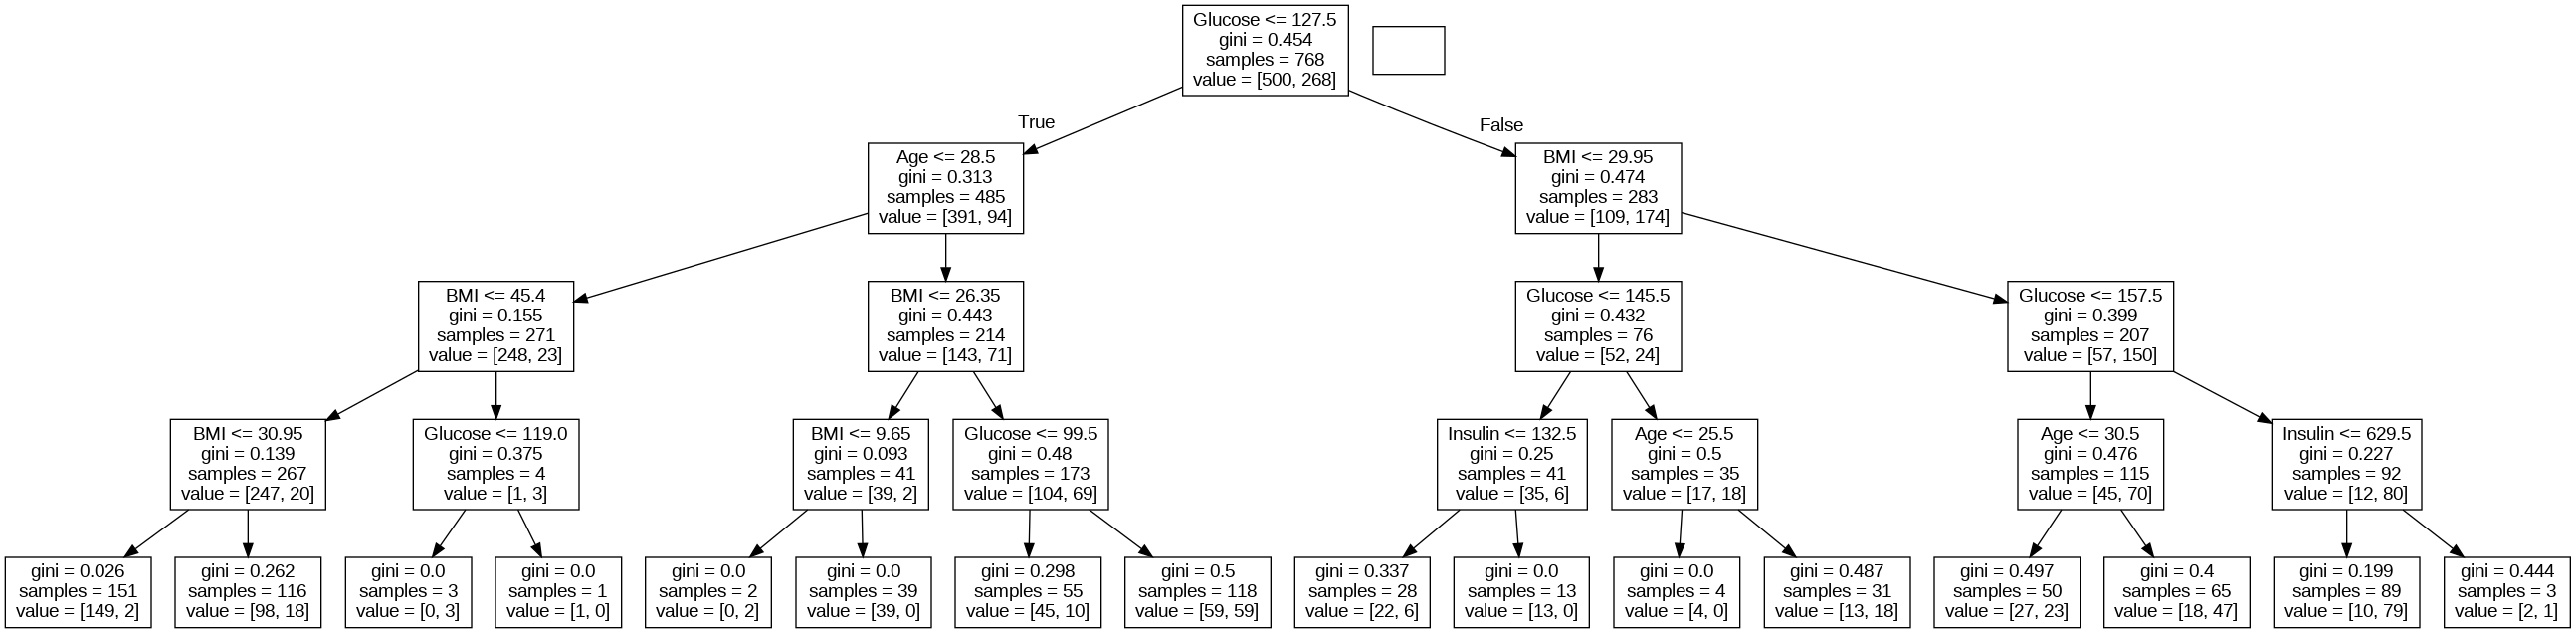

**Análisis de resultados**

 A partir del árbol de decisión generado con la base de datos de diabetes se observa un total de 768 registros, donde 500 pacientes no presentan diabetes y 268 sí presentan la enfermedad. En el nodo raíz el árbol divide inicialmente por Glucose ≤ 127.5, lo que indica que el nivel de glucosa es la variable más importante para la clasificación. Posteriormente, el modelo utiliza variables como Age y BMI para continuar las divisiones y mejorar la capacidad de clasificación.

Dentro del árbol se identifican 6 nodos puros (gini = 0), lo que significa que en esas condiciones el modelo clasifica a los pacientes con 100% de certeza dentro del conjunto analizado.

De acuerdo con el árbol de decisión se destaca el primer nodo puro por la izquierda [0,3] el cual posee la siguiente regla de decisión: Si una persona cumple con esta,
If Gluclose ≤ 127.5 and Age ≤ 28.5 and BMI > 45.4 and Glucose ≤ 119.0 Then No Disease / Disease → 0 / 3 → 0% / 100% (100% Disease)

Segundo nodo [1,0]: If Glucose ≤ 127.5 and Age ≤ 28.5 and BMI > 45.4 and Glucose > 119 Then No Disease / Disease → 1 / 0 → 100% / 0% (100% No Disease)

Tercer nodo [0,2]: If Glucose ≤ 127.5 and Age > 28.5 and BMI ≤ 26.35 and BMI ≤ 9.65 Then No Disease / Disease → 0 / 2 → 0% / 100% (100% Disease)

Cuarto nodo [39,0]: If Glucose ≤ 127.5 and Age > 28.5 and BMI ≤ 26.35 and BMI > 9.65 Then No Disease / Disease → 39 / 0 → 100% / 0% (100% No Disease)

Quinto nodo [13,0]: If Glucose > 127.5 and BMI ≤ 29.95 and Glucose ≤ 145.5 and Insulin > 132.5 Then No Disease / Disease → 13 / 0 → 100% / 0% (100% No Disease)

Sexto nodo [4,0]: If Glucose > 127.5 and BMI ≤ 29.95 and Glucose > 145.5 and Age ≤ 25.5 Then No Disease / Disease → 4 / 0 → 100% / 0% (100% No Disease)

**5. Se evalúa a la paciente**

In [ ]:
XDp2 = [2, 85, 65, 29, 94, 39.6, 0.93, 27] #'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
ydc2 = mar.predict([XDp2])
print(ydc2)

if ydc2==1:
  print("La paciente analizada es clasificada con diabetes")
else:
  print("La paciente analizada es clasificada sin diabetes")

[0]
La paciente analizada es clasificada sin diabetes


**Análisis de resultados**

Al evaluar a la paciente con las características [2, 85, 65, 29, 94, 39.6, 0.93, 27] utilizando el modelo de árbol de decisión, el resultado obtenido es 0, lo que indica que el modelo la clasifica como sin diabetes. Esto significa que, según las reglas aprendidas por el árbol durante el entrenamiento, la combinación de estos valores se asemeja más a los registros de pacientes que no presentan diabetes dentro del conjunto de datos.

##**Modelo Clustering K-Means**

**0. Se cargan las librerías específicas**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns   #Herramientas para gráficas estadísticas

from sklearn.cluster import KMeans  #Herramienta de Clustering

**1. Se cargan los datos de trabajo y se hace el análisis de correlación**

<Axes: >

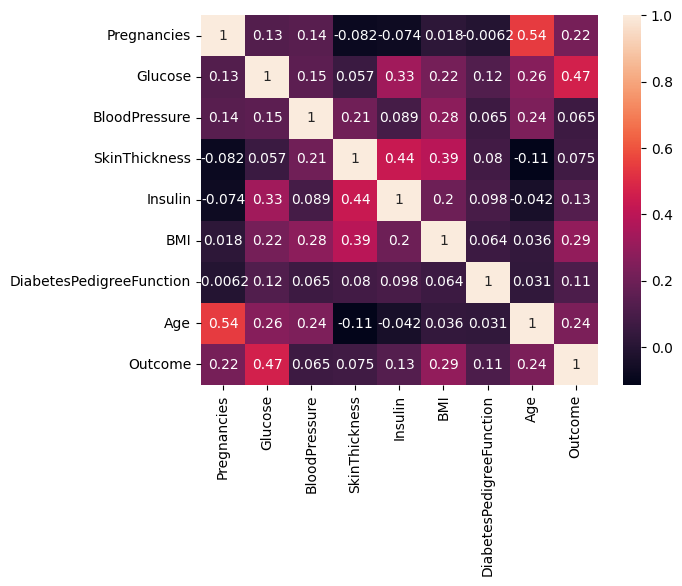

In [ ]:
XD3 = XDB.iloc[:,[0, 1, 2, 3, 4, 5, 6, 7]]
yd3 = XDB.iloc[:,8]

#Determinamos la correlación entre las variables
XDB2 = XDB.iloc[:,[0, 1, 2, 3, 4, 5, 6, 7, 8]]
sns.heatmap(XDB2.corr(), annot = True)

**Análisis de resultados**

En el heatmap se observa que la variable que tiene mayor correlación con la variable de salida (Outcome) es Glucose, con un valor de 0.47. Esto indica una relación positiva moderada, lo que significa que cuando los valores de glucosa aumentan, también aumenta la probabilidad de que la paciente sea clasificada con diabetes dentro del conjunto de datos. Por esta razón, la glucosa se puede considerar una de las variables más influyentes para la clasificación.

Otra correlación relevante es la de BMI con Outcome (0.29) y Age con Outcome (0.24). Aunque estas correlaciones son más bajas, siguen siendo positivas, lo que indica que estas variables también tienen cierta relación con la presencia de diabetes en los registros analizados.

Entre las variables de entrada, la mayor correlación del mapa es entre Pregnancies y Age (0.54), lo que muestra una relación positiva fuerte entre estas dos variables. También se observa una correlación importante entre SkinThickness e Insulin (0.44), lo que indica que cuando aumenta el espesor del pliegue cutáneo, también tienden a aumentar los valores de insulina en los datos.

Finalmente, se observa que varias variables tienen correlaciones bajas cercanas a cero, especialmente DiabetesPedigreeFunction, que muestra poca relación con la mayoría de las otras variables. Esto indica que esta variable aporta información más independiente dentro del conjunto de datos.

**2. Se implementa el modelo K-Means**

In [ ]:
np.random.seed(42)
NC = 5
mkm = KMeans(n_clusters = NC, random_state = 42)
mkm.fit(XD3,yd3)

#Características de cada grupo
tabla = pd.DataFrame(mkm.cluster_centers_,columns = XD3.columns)
display(tabla)

#Porcentajes
ydp3 = mkm.labels_
NDc = np.bincount(ydp3)
print()
print("El número de datos por cluster es: ", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,3.490826,128.339450,71.321101,30.229358,158.000000,33.951835,0.479950,31.366972
1,4.487179,133.948718,76.948718,24.769231,95.717949,34.702564,1200.871795,36.512821
2,3.968017,113.409382,67.275053,14.718550,14.405117,30.660981,0.384576,33.716418
3,1.375000,140.625000,66.500000,28.250000,197.625000,31.675000,1944.500000,29.000000
4,4.264706,156.794118,71.764706,31.970588,434.470588,34.764706,0.441647,35.941176



El número de datos por cluster es:  [218  39 469   8  34]


**Análisis de resultados**

El modelo de K-Means se aplicó con 5 clusters, con el objetivo de agrupar pacientes que presentan valores promedio específicos en las variables analizadas. A partir de los resultados, se observa que el cluster 2 es el grupo más grande con 469 pacientes, seguido por el cluster 0 con 218 pacientes, mientras que los clusters 1, 4 y 3 contienen una cantidad mucho menor de registros. Esto indica que la mayoría de los pacientes del conjunto de datos comparten características similares a las representadas por el cluster 2.

El cluster 4 presenta los valores más altos de glucosa (156.79) y de insulina (434.47), lo que indica que los pacientes de este grupo tienen niveles más elevados en estas variables. También se observa que el cluster 3 presenta valores altos de glucosa (140.63) e insulina (197.63), aunque es un grupo muy pequeño con solo 8 registros. En contraste, el cluster más grande (el 2) muestra los valores más bajos de glucosa (113.41) e insulina (14.41) en comparación con los otros grupos, lo que sugiere que este cluster representa pacientes con características más cercanas a valores normales dentro del conjunto de datos.

**3. Porcentajes de pacientes con diabetes**

In [ ]:
XDB2["Cluster"] = ydp3
display (XDB2)

NApr = XDB2.groupby('Cluster').agg({'Outcome': lambda x: (x==1).sum()})
NPrn = XDB2.groupby('Cluster').agg({'Outcome': lambda x: (x==0).sum()})

#Decisión en porcentaje
NApr2 = NApr / (NApr + NPrn)
NPrn2 = NPrn / (NApr + NPrn)
df2 = pd.DataFrame(np.column_stack((NApr,NPrn)),columns = ['Con diabetes', 'Sin diabetes'])
display(df2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,2
1,1,85,66,29,0,26.6,0.351,31,0,2
2,8,183,64,0,0,23.3,0.672,32,1,2
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2288.000,33,1,3
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0
764,2,122,70,27,0,36.8,0.340,27,0,2
765,5,121,72,23,112,26.2,0.245,30,0,0
766,1,126,60,0,0,30.1,0.349,47,1,2


,Con diabetes,Sin diabetes
0,86,132
1,24,15
2,135,334
3,3,5
4,20,14


**4. Evaluación de una nueva paciente**

**Análisis de resultados**

A partir de la agrupación realizada con K-Means, se puede observar cómo se distribuyen los pacientes con y sin diabetes dentro de cada cluster. En el cluster 0 se identifican 86 pacientes con diabetes y 132 sin diabetes, lo que indica que en este grupo predominan los pacientes que no presentan la enfermedad. Asimismo, el cluster 2 es el grupo más grande y contiene 135 pacientes con diabetes y 334 sin diabetes, por lo que también predominan los pacientes sin diabetes en este cluster.

Por otro lado, el cluster 1 presenta 24 pacientes con diabetes y 15 sin diabetes, lo que significa que en este grupo hay una mayor proporción de pacientes con diabetes. Algo similar ocurre en el cluster 4, donde hay 20 pacientes con diabetes y 14 sin diabetes, mostrando también una mayor presencia relativa de pacientes con la enfermedad. En cambio, el cluster 3 es el grupo más pequeño, con 3 pacientes con diabetes y 5 sin diabetes, por lo que su representación dentro del conjunto de datos es muy baja.

En general, estos resultados muestran que algunos clusters agrupan principalmente pacientes sin diabetes, mientras que otros presentan una mayor proporción de pacientes con diabetes.

In [ ]:
nueva_paciente = np.array([2, 85, 65, 29, 94, 39.6, 0.93, 27])
ydp4 = mkm.predict(nueva_paciente.reshape(1,-1))
NCl = ydp4[0]
print('La nueva paciente pertenece al cluster: ',ydp4)
print()
print('El porcentaje de que la paciente tenga un resultado positivo es: ', NApr2.iloc[NCl])
print()
print('El porcentaje de que la paciente tenga un resultado negativo es: ', NPrn2.iloc[NCl])

La nueva paciente pertenece al cluster:  [0]

El porcentaje de que la paciente tenga un resultado positivo es:  Outcome    0.394495
Name: 0, dtype: float64

El porcentaje de que la paciente tenga un resultado negativo es:  Outcome    0.605505
Name: 0, dtype: float64


**Análisis de resultados**

El modelo K-Means asignó a la nueva paciente al cluster 0. Dentro de ese grupo, el análisis de los datos indica que aproximadamente 39.45% de los casos presentan un resultado positivo de diabetes, mientras que 60.55% presentan un resultado negativo. Esto significa que, según las características de la paciente, su perfil es más similar al de pacientes que no tienen diabetes, ya que la mayoría de los individuos en ese cluster tienen resultado negativo.

**5.Gráfica de los clusters**

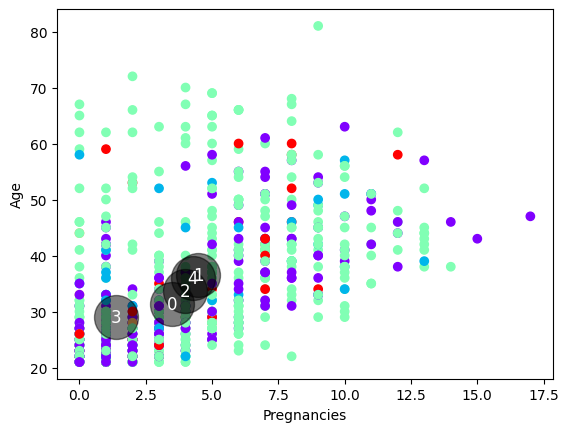

In [ ]:
centers = mkm.cluster_centers_
pregnancies = np.array(XD.iloc[:,0]); age = np.array(XD.iloc[:,7])

plt.figure()
plt.scatter(pregnancies, age, c=mkm.labels_, cmap='rainbow')
plt.scatter(centers[:,0], centers[:,7], c='black', s=1000, alpha=0.5)
plt.xlabel("Pregnancies")
plt.ylabel("Age")

# Añadir números a los centros
for i, center in enumerate(centers):
  plt.text(center[0], center[7], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()


**Conclusión final**

Recomendaria el modelo de Árbol de Decisión para este problema. Aunque modelos como Naive Bayes o K-Means pueden ofrecer buenos resultados, el árbol de decisión tiene la gran ventaja de ser más fácil de interpretar. El modelo muestra de forma clara qué variables influyen en la predicción, por ejemplo niveles de glucosa, BMI, edad o presión arterial, y cómo cada condición lleva a una clasificación final. Esto es especialmente importante en el área médica, donde los profesionales necesitan entender y justificar las decisiones del modelo antes de aplicarlas en pacientes.

Además, el árbol permite visualizar reglas simples que facilitan identificar pacientes con mayor o menor riesgo de diabetes. Desde el punto de vista del negocio o de la clínica, esto ayuda a priorizar recursos, monitorear pacientes de alto riesgo y apoyar la toma de decisiones médicas de forma transparente.

Por estas razones, considerando no solo las métricas obtenidas sino también la facilidad de interpretación y aplicación práctica, el Árbol de Decisión resulta una opción muy adecuada para este problema.